In [1]:
!pip install scikit-learn


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 24.3.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# 1️⃣ Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score



In [3]:
df = pd.read_csv("Insurance.csv")

df.head()

,age,sex,bmi,children,smoker,region,charges,insuranceclaim
0,19,0,27.900,0,1,3,16884.92400,1
1,18,1,33.770,1,0,2,1725.55230,1
2,28,1,33.000,3,0,2,4449.46200,0
3,33,1,22.705,0,0,1,21984.47061,0
4,32,1,28.880,0,0,1,3866.85520,1


✅ Dataset loaded successfully!

   age  sex     bmi  children  smoker  region      charges  insuranceclaim
0   19    0  27.900         0       1       3  16884.92400               1
1   18    1  33.770         1       0       2   1725.55230               1
2   28    1  33.000         3       0       2   4449.46200               0
3   33    1  22.705         0       0       1  21984.47061               0
4   32    1  28.880         0       0       1   3866.85520               1 

🔹 Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             1338 non-null   int64  
 1   sex             1338 non-null   int64  
 2   bmi             1338 non-null   float64
 3   children        1338 non-null   int64  
 4   smoker          1338 non-null   int64  
 5   region          1338 non-null   int64  
 6   charges         1338 non-null   float

C:\Users\N54447\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


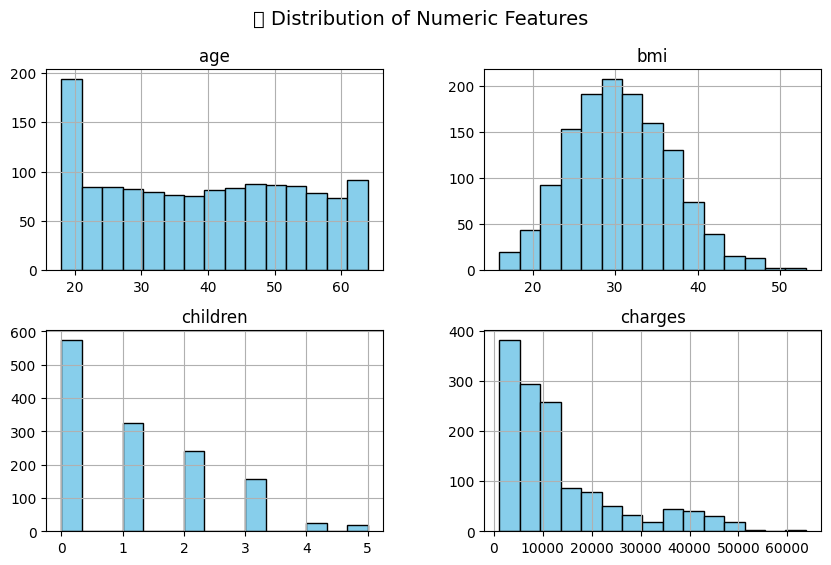

C:\Users\N54447\AppData\Local\Temp\ipykernel_28120\2100800969.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=data[col], palette='Set2')
C:\Users\N54447\AppData\Local\Temp\ipykernel_28120\2100800969.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=data[col], palette='Set2')
C:\Users\N54447\AppData\Local\Temp\ipykernel_28120\2100800969.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=data[col], palette='Set2')
C:\Users\N54447\AppData\Local\Temp\ipykernel_28120\2100800969.py:41: FutureWarning: 

Passing `palette` witho

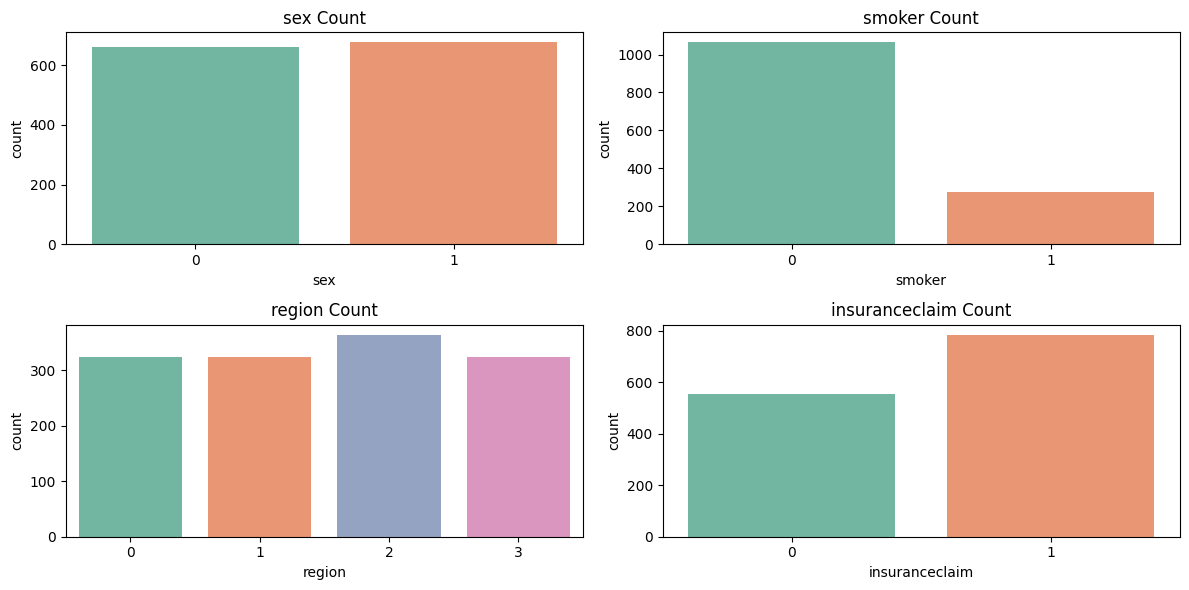

C:\Users\N54447\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


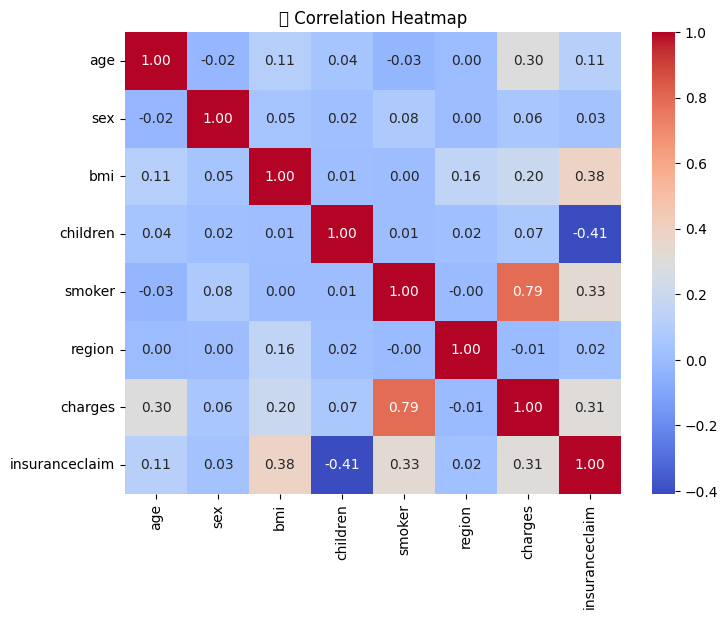

C:\Users\N54447\AppData\Local\Temp\ipykernel_28120\2100800969.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='smoker', y='charges', data=data, palette="Set3")
C:\Users\N54447\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


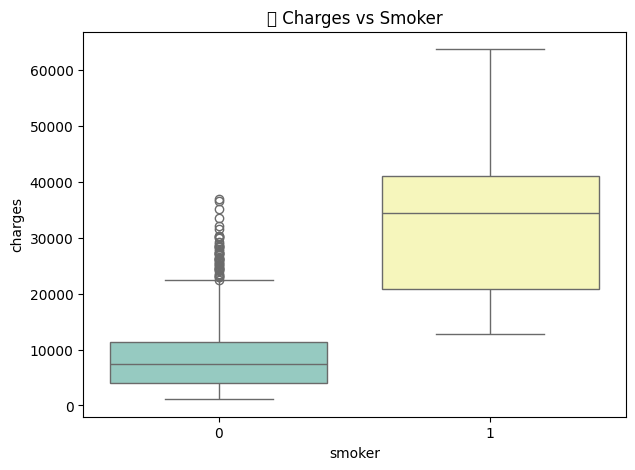


🔹 Missing values:
 age         0
bmi         0
children    0
charges     0
sex_1       0
region_1    0
region_2    0
region_3    0
smoker_1    0
dtype: int64

✅ After encoding and scaling:
        age       bmi  children   charges  sex_1  region_1  region_2  \
0 -1.438764 -0.453320 -0.908614  0.298584  False     False     False   
1 -1.509965  0.509621 -0.078767 -0.953689   True     False      True   
2 -0.797954  0.383307  1.580926 -0.728675   True     False      True   
3 -0.441948 -1.305531 -0.908614  0.719843   True      True     False   
4 -0.513149 -0.292556 -0.908614 -0.776802   True      True     False   

   region_3  smoker_1  
0      True      True  
1     False     False  
2     False     False  
3     False     False  
4     False     False  

🔹 Data types:
 age         float64
bmi         float64
children    float64
charges     float64
sex_1         int64
region_1      int64
region_2      int64
region_3      int64
smoker_1      int64
dtype: object

📊 Train size: 1070
📊 T

C:\Users\N54447\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 129513 (\N{JIGSAW PUZZLE PIECE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


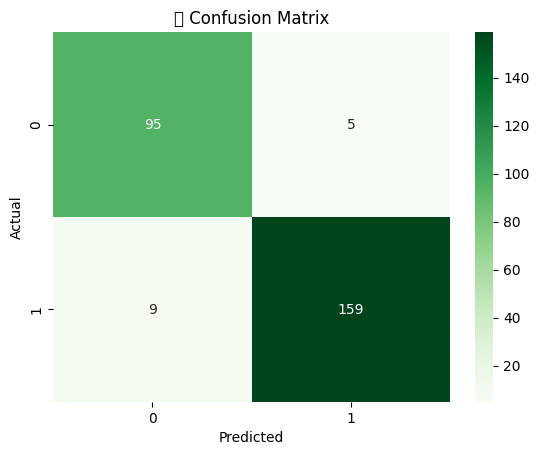


🧠 Demo Prediction on one sample:
Predicted Insurance Claim: 1
Actual Insurance Claim: 1


In [8]:
# 1️⃣ Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# ---------------------------------------------
# 2️⃣ Load dataset
# ---------------------------------------------
data = pd.read_csv("Insurance.csv")
print("✅ Dataset loaded successfully!\n")
print(data.head(), "\n")

# ---------------------------------------------
# 3️⃣ Basic information
# ---------------------------------------------
print("🔹 Info:")
print(data.info())
print("\n🔹 Missing values:\n", data.isnull().sum())
print("\n🔹 Summary statistics:\n", data.describe())

# ---------------------------------------------
# 4️⃣ Exploratory Data Analysis
# ---------------------------------------------
num_features = ['age', 'bmi', 'children', 'charges']
data[num_features].hist(bins=15, figsize=(10, 6), color='skyblue', edgecolor='black')
plt.suptitle("📊 Distribution of Numeric Features", fontsize=14)
plt.show()

cat_features = ['sex', 'smoker', 'region', 'insuranceclaim']
plt.figure(figsize=(12, 6))
for i, col in enumerate(cat_features, 1):
    plt.subplot(2, 2, i)
    sns.countplot(x=data[col], palette='Set2')
    plt.title(f"{col} Count")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
sns.heatmap(data.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("🔥 Correlation Heatmap")
plt.show()

plt.figure(figsize=(7, 5))
sns.boxplot(x='smoker', y='charges', data=data, palette="Set3")
plt.title("💰 Charges vs Smoker")
plt.show()

# ---------------------------------------------
# 5️⃣ Preprocessing
# ---------------------------------------------
# Separate features and target
X = data.drop('insuranceclaim', axis=1)
y = data['insuranceclaim'].values

# One-hot encode categorical variables
X = pd.get_dummies(X, columns=['sex', 'region', 'smoker'], drop_first=True)

# Check for missing values
print("\n🔹 Missing values:\n", X.isnull().sum())

# Fill or drop missing values if necessary
X.fillna(X.mean(), inplace=True)

# Scale numerical columns
scaler = StandardScaler()
num_cols = ['age', 'bmi', 'children', 'charges']
X[num_cols] = scaler.fit_transform(X[num_cols])

print("\n✅ After encoding and scaling:")
print(X.head())

# Convert boolean columns to integers (0/1)
for col in X.select_dtypes('bool').columns:
    X[col] = X[col].astype(int)

# Ensure all columns are numeric
X = X.apply(pd.to_numeric, errors='coerce')
X.fillna(0, inplace=True)  # Fill any remaining NaNs with 0

print("\n🔹 Data types:\n", X.dtypes)

# Convert to PyTorch tensors
X_tensor = torch.tensor(X.values, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.long)

# Create dataset and split
dataset = TensorDataset(X_tensor, y_tensor)
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print("\n📊 Train size:", train_size)
print("📊 Test size:", test_size)

# ---------------------------------------------
# 6️⃣ Build the Neural Network
# ---------------------------------------------
class NeuralNet(nn.Module):
    def __init__(self, input_size, hidden_sizes, output_size):
        super(NeuralNet, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_sizes[0])
        self.fc2 = nn.Linear(hidden_sizes[0], hidden_sizes[1])
        self.fc3 = nn.Linear(hidden_sizes[1], output_size)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        return x

input_size = X.shape[1]
hidden_sizes = [16, 8]
output_size = len(np.unique(y))

model = NeuralNet(input_size, hidden_sizes, output_size)

# Define loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# ---------------------------------------------
# 7️⃣ Train the Model
# ---------------------------------------------
num_epochs = 100
for epoch in range(num_epochs):
    model.train()
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

    if (epoch+1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')

# ---------------------------------------------
# 8️⃣ Evaluate the Model
# ---------------------------------------------
model.eval()
y_pred = []
y_true = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        outputs = model(X_batch)
        _, predicted = torch.max(outputs.data, 1)
        y_pred.extend(predicted.numpy())
        y_true.extend(y_batch.numpy())

print("\n✅ Model Evaluation:")
print("Accuracy:", accuracy_score(y_true, y_pred))
print("\nClassification Report:\n", classification_report(y_true, y_pred))

cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title("🧩 Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ---------------------------------------------
# 9️⃣ Demo Prediction
# ---------------------------------------------
# Select a sample from the test set
sample = test_dataset[0][0].unsqueeze(0)  # Add batch dimension

model.eval()
with torch.no_grad():
    output = model(sample)
    _, predicted = torch.max(output.data, 1)

print("\n🧠 Demo Prediction on one sample:")
print("Predicted Insurance Claim:", predicted.item())
print("Actual Insurance Claim:", test_dataset[0][1].item())
